In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:98% !important;}
div.cell.code_cell.rendered{width:98%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:22px;}
</style>
"""))

In [21]:
import numpy as np
import pandas as pd
import seaborn as sns # iris 가져오기
from sklearn import datasets # iris(x와 y가 분리되서 numpy)가져오기
from sklearn.preprocessing import LabelEncoder # 라벨인코더
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import ReLU, ELU, LeakyReLU, Dropout
from tensorflow.keras.layers import Dense, Input, BatchNormalization

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt

```
- 데이터셋 생성 및 전처리
    X,y (라벨인코딩)분리 - > train_test_split 분리(8:2)
- 모델 구성(입력4, 출력3, layer : 입력 4 ->64 ->128 -> 50 -> 30 -> 출력 3)
- 학습과정 설정(loss = 'sparse_categorical_crossentropy')
- 학습
- 모델평가(가장 최선의 모델을 get하기위한 작업)
- 모델사용(저장/예측)
    
```
# 1. 데이터셋 생성 및 전처리

In [12]:
#seaborn으로 데이터셋 생성(방법1)
iris = sns.load_dataset('iris')
iris['species'].value_counts()

setosa        50
versicolor    50
virginica     50
Name: species, dtype: int64

In [27]:
iris_X=iris.iloc[:,:-1].values
labelEncoder =LabelEncoder()
iris_y=labelEncoder.fit_transform(iris.iloc[:,-1]) 
iris_X.shape , iris_y.shape

((150, 4), (150,))

In [30]:
#sklearn으로 데이터셋 생성(방법2)
iris=datasets.load_iris()
iris_X=iris.data
iris_y=iris.target

In [36]:
print(iris.target_names)
iris_X.shape , iris_y.shape

['setosa' 'versicolor' 'virginica']


((150, 4), (150,))

In [44]:
#학습셋과 테스트셋 분리
train_X, test_X, train_y, test_y =train_test_split(iris_X,iris_y,
                                                   test_size=0.2,
                                                   stratify=iris_y #층화추출
                                                  )

In [45]:
np.c_[pd.Series(iris_y).value_counts(normalize=True),
      pd.Series(train_y).value_counts(normalize=True),
      pd.Series(test_y).value_counts(normalize=True)]

array([[0.33333333, 0.33333333, 0.33333333],
       [0.33333333, 0.33333333, 0.33333333],
       [0.33333333, 0.33333333, 0.33333333]])

In [46]:
train_X.shape, test_X.shape, train_y.shape, test_y.shape

((120, 4), (30, 4), (120,), (30,))

# 2. 모델구성 및 학습
- 모델 구성(입력4, 출력3, layer : 입력 4 ->64 ->128 -> 50 -> 30 -> 출력 3)
- He초기화, 다양한 activation, 배치정규화, L2정규화, Dropout

In [49]:
model = Sequential([
    Input(4),
    Dense(units=64, activation='relu'),
    Dense(units=128, activation='relu'),
    Dense(units=50, activation='relu'),
    Dense(units=30, activation='relu'),
    Dense(units=3, activation='softmax')
],name='sequential')
# model.add(Input(4))
# model.add(Dense(units=64, activation='relu'))
# model.add(Dense(units=128, activation='relu'))
# model.add(Dense(units=50, activation='relu'))
# model.add(Dense(units=30, activation='relu'))
# model.add(Dense(units=3, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_10 (Dense)            (None, 64)                320       
                                                                 
 dense_11 (Dense)            (None, 128)               8320      
                                                                 
 dense_12 (Dense)            (None, 50)                6450      
                                                                 
 dense_13 (Dense)            (None, 30)                1530      
                                                                 
 dense_14 (Dense)            (None, 3)                 93        
                                                                 
Total params: 16,713
Trainable params: 16,713
Non-trainable params: 0
_________________________________________________________________


In [60]:
%%time
model.compile(loss='sparse_categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])
earlystopping=EarlyStopping(patience=40) #monitor ='val_loss'
model_save_folder ='model/'
file =model_save_folder + 'iris-{epoch:03d}-loss{val_loss:.4f}-acc{val_accuracy:.4f}.h5'
checkpoint = ModelCheckpoint(monitor='val_accuracy',
                            filepath=file,  # 모델 저장파일
                            save_best_only=True,  #모니터 지표가 개선도니 경우에만 모델저장
                            mode='max',
                            verbose=1) #저장여부 로그출력
hist=model.fit(train_X, train_y, epochs=200,
              validation_split=0.1,
              callbacks=[earlystopping, checkpoint],
              verbose=2)

Epoch 1/200

Epoch 1: val_accuracy improved from -inf to 0.91667, saving model to model\iris-001-loss0.1403-acc0.9167.h5
4/4 - 1s - loss: 0.0769 - accuracy: 0.9722 - val_loss: 0.1403 - val_accuracy: 0.9167 - 833ms/epoch - 208ms/step
Epoch 2/200

Epoch 2: val_accuracy improved from 0.91667 to 1.00000, saving model to model\iris-002-loss0.0345-acc1.0000.h5
4/4 - 0s - loss: 0.0496 - accuracy: 0.9815 - val_loss: 0.0345 - val_accuracy: 1.0000 - 62ms/epoch - 15ms/step
Epoch 3/200

Epoch 3: val_accuracy did not improve from 1.00000
4/4 - 0s - loss: 0.0499 - accuracy: 0.9907 - val_loss: 0.1244 - val_accuracy: 0.9167 - 41ms/epoch - 10ms/step
Epoch 4/200

Epoch 4: val_accuracy did not improve from 1.00000
4/4 - 0s - loss: 0.0714 - accuracy: 0.9722 - val_loss: 0.2027 - val_accuracy: 0.9167 - 45ms/epoch - 11ms/step
Epoch 5/200

Epoch 5: val_accuracy did not improve from 1.00000
4/4 - 0s - loss: 0.0417 - accuracy: 0.9907 - val_loss: 0.0199 - val_accuracy: 1.0000 - 41ms/epoch - 10ms/step
Epoch 6/200

# 3. 모델평가

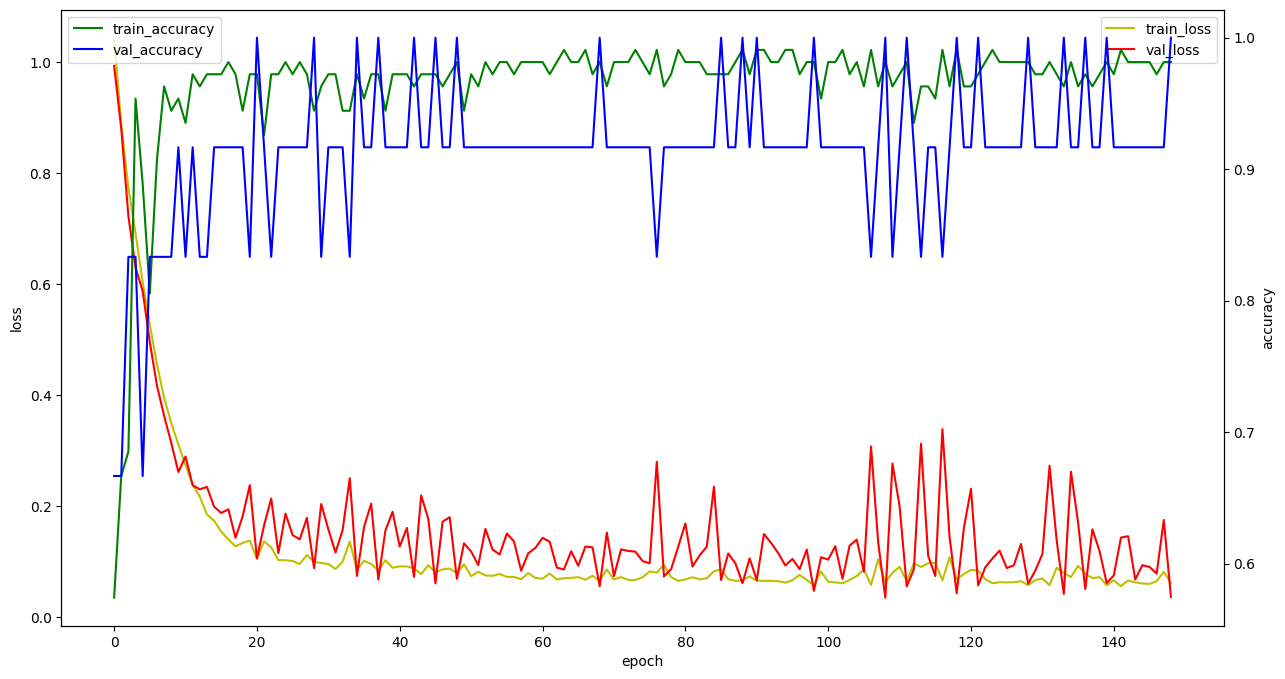

In [55]:
# 학습과정살펴보기 (시각화)
fig, loss_ax=plt.subplots(figsize=(15,8))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax=loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'],'b',label='val_accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend()
acc_ax.legend()
plt.show()

In [53]:
# 모델 평가
model.evaluate(test_X,test_y)

1/1 [==============================] - 0s 21ms/step - loss: 0.0394 - accuracy: 1.0000


[0.0394209623336792, 1.0]

In [61]:
loss, acc =model.evaluate(test_X,test_y)
print(loss, acc)

1/1 [==============================] - 0s 21ms/step - loss: 0.0085 - accuracy: 1.0000
0.008464000187814236 1.0


In [64]:
model1=load_model('model/iris-002-loss0.0345-acc1.0000.h5')
loss1, acc1 =model1.evaluate(test_X,test_y)
print(loss, acc)

1/1 [==============================] - 0s 208ms/step - loss: 0.0192 - accuracy: 1.0000
0.008464000187814236 1.0


# 2. sklearn 이용
- 입력 4 ->64 ->128 -> 50 -> 30 -> 출력 3

In [65]:
from sklearn.neural_network import MLPClassifier #multi-layer perceptron
#1. 데이터
train_X.shape, train_y.shape, test_X.shape, test_y.shape

((120, 4), (120,), (30, 4), (30,))

In [66]:
#2. 모델생성
model =MLPClassifier(hidden_layer_sizes=(64,128,50,30),
                    activation='relu',
                    solver='adam',# 옵티마이저
                    batch_size=40,#학습시 batch_size
                    early_stopping=True, #조기 종료 활성화
                    n_iter_no_change=50, #earlystopping의 patience역할
                    validation_fraction=0.1,
                    max_iter=200,
                    warm_start=False #True일 경우 이전학습에 이어서 학습
                    )

In [67]:
#3. 모델학습
model.fit(train_X, train_y)

MLPClassifier(batch_size=40, early_stopping=True,
              hidden_layer_sizes=(64, 128, 50, 30), n_iter_no_change=50)

In [69]:
#4. 모델평가
model.score(test_X,test_y)

1.0

In [74]:
# 5. 교차표(혼동행렬)
# 실제값 : test_y
y_hat = model.predict(test_X)

In [75]:
pd.crosstab(test_y,y_hat,rownames=["real"], colnames=["predict"])

predict,0,1,2
real,,,
0,10,0,0
1,0,10,0
2,0,0,10


In [76]:
from sklearn.metrics import confusion_matrix, recall_score, precision_score

# 3. 클래스를 생성하여 모델 생성함수 사용

In [77]:
class DNNClassifier:
    @staticmethod
    def build(input_dim=4, activation='relu', output_dim=3, optimizer='adam'):
        #모델구성
        model =Sequential(layers=[
            Input(input_dim),
            Dense(units=50, activation=activation),
            Dense(units=30, activation=activation),
            Dense(units=output_dim, activation='softmax')],
            name='sequential')
        #모델학습설정
        model.compile(loss='sparse_categorical_crossentropy',
                     optimizer=optimizer,
                     metrics=['accuracy'])
        #모델return
        return model

In [81]:
#1. 데이터
print(train_X.shape, train_y.shape, test_X.shape, test_y.shape)
#2. 모델
model = DNNClassifier.build(input_dim=4, activation='relu', output_dim=3,optimizer='adam')
#3. 모델 학습
hist =model.fit(train_X, train_y, epochs=50, validation_split=0.1,verbose=1)

(120, 4) (120,) (30, 4) (30,)
Epoch 1/50
4/4 [==============================] - 1s 63ms/step - loss: 1.9110 - accuracy: 0.4630 - val_loss: 1.1476 - val_accuracy: 0.8333
Epoch 2/50
4/4 [==============================] - 0s 11ms/step - loss: 1.5379 - accuracy: 0.6389 - val_loss: 0.9912 - val_accuracy: 0.8333
Epoch 3/50
4/4 [==============================] - 0s 13ms/step - loss: 1.2197 - accuracy: 0.6296 - val_loss: 0.8921 - val_accuracy: 0.8333
Epoch 4/50
4/4 [==============================] - 0s 11ms/step - loss: 0.9759 - accuracy: 0.6296 - val_loss: 0.8673 - val_accuracy: 0.8333
Epoch 5/50
4/4 [==============================] - 0s 11ms/step - loss: 0.8544 - accuracy: 0.7593 - val_loss: 0.9097 - val_accuracy: 0.6667
Epoch 6/50
4/4 [==============================] - 0s 11ms/step - loss: 0.8304 - accuracy: 0.6667 - val_loss: 0.9612 - val_accuracy: 0.6667
Epoch 7/50
4/4 [==============================] - 0s 12ms/step - loss: 0.8399 - accuracy: 0.6667 - val_loss: 0.9598 - val_accuracy: 0.66

In [83]:
# 모델평가
loss, accuracy = model.evaluate(test_X,test_y, verbose=0)
print(f'정확도 : {accuracy*100}%')

정확도 : 100.0%


# 4. 함수형 API


In [87]:
# 기존 model 스타일
model =Sequential(layers=[
    Input(shape=(4,)),
    Dense(units=50,activation='relu'),
    Dense(units=30,activation='relu'),
    Dense(units=3,activation='softmax'),
])
# 기존 model 스타일2
model =Sequential()
model.add(Input(shape=(4,)))
model.add(Dense(units=50,activation='relu'))
model.add(Dense(units=30,activation='relu'))
model.add(Dense(units=3,activation='softmax'))
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_30 (Dense)            (None, 50)                250       
                                                                 
 dense_31 (Dense)            (None, 30)                1530      
                                                                 
 dense_32 (Dense)            (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________


In [86]:
# 함수형 API 스타일
from tensorflow.keras import Model
input_=Input(4)
layer1=Dense(units=50, activation='relu')(input_)
layer2=Dense(units=30, activation='relu')(layer1)
output=Dense(units=3, activation='softmax')(layer2)
model = Model(inputs=input_, outputs=output)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_7 (InputLayer)        [(None, 4)]               0         
                                                                 
 dense_24 (Dense)            (None, 50)                250       
                                                                 
 dense_25 (Dense)            (None, 30)                1530      
                                                                 
 dense_26 (Dense)            (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________


In [ ]:
# 입력 4 -> 160 -> 출력3 
model =Sequential([
    Input(4),
    Dense(units=160, activation='relu')
    Dense(units=3, activation='softmax')
])

In [88]:
# 함수형 API 스타일
input_=Input(4)
layer=Dense(units=160, activation='relu')(input_)
output=Dense(units=3, activation='softmax')(layer)
model = Model(inputs=input_, outputs=output)
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_10 (InputLayer)       [(None, 4)]               0         
                                                                 
 dense_33 (Dense)            (None, 160)               800       
                                                                 
 dense_34 (Dense)            (None, 3)                 483       
                                                                 
Total params: 1,283
Trainable params: 1,283
Non-trainable params: 0
_________________________________________________________________


In [93]:
#병렬처리 입력 4 -> 160 -> 출력3 
from tensorflow.keras.layers import concatenate
input_=Input(4)
dense1 = Dense(units=50, activation='relu')(input_)
dense2 = Dense(units=80, activation='relu')(input_)
dense3 = Dense(units=30, activation='relu')(input_)
x      = concatenate([dense1, dense2, dense3])
output=Dense(units=3, activation='softmax')(x)
model = Model(inputs=input_, outputs=output)
model.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_15 (InputLayer)          [(None, 4)]          0           []                               
                                                                                                  
 dense_51 (Dense)               (None, 50)           250         ['input_15[0][0]']               
                                                                                                  
 dense_52 (Dense)               (None, 80)           400         ['input_15[0][0]']               
                                                                                                  
 dense_53 (Dense)               (None, 30)           150         ['input_15[0][0]']               
                                                                                            

In [94]:
#레지듀얼 블럭(Residual block)
from tensorflow.keras.layers import add
input_=Input(4)
dense1 = Dense(units=50, activation='relu')(input_)
layer1 = Dense(units=64, activation='relu')(dense1)
layer2 = Dense(units=50, activation='relu')(layer1)
dense2 = add([dense1, layer2])
output=Dense(units=3, activation='softmax')(dense2)
model = Model(inputs=input_, outputs=output)
model.summary()

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_16 (InputLayer)          [(None, 4)]          0           []                               
                                                                                                  
 dense_55 (Dense)               (None, 50)           250         ['input_16[0][0]']               
                                                                                                  
 dense_56 (Dense)               (None, 64)           3264        ['dense_55[0][0]']               
                                                                                                  
 dense_57 (Dense)               (None, 50)           3250        ['dense_56[0][0]']               
                                                                                            